In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
# Sampling Library
from sklearn.model_selection import train_test_split

# Data Transformation Libraries
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

# Custom Transformation
from sklearn.base import BaseEstimator, TransformerMixin

# Data Pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Machine Learning Models and Evaluation Metrices
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Custom Evaluation Metric
def rmse(y, y_hat):
    return np.sqrt(mean_squared_error(y, y_hat))


In [2]:
file_path='co2 Emissions.csv'

In [3]:
df=pd.read_csv(file_path)

In [4]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [5]:
df.tail()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
7380,VOLVO,XC40 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,10.7,7.7,9.4,30,219
7381,VOLVO,XC60 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,11.2,8.3,9.9,29,232
7382,VOLVO,XC60 T6 AWD,SUV - SMALL,2.0,4,AS8,Z,11.7,8.6,10.3,27,240
7383,VOLVO,XC90 T5 AWD,SUV - STANDARD,2.0,4,AS8,Z,11.2,8.3,9.9,29,232
7384,VOLVO,XC90 T6 AWD,SUV - STANDARD,2.0,4,AS8,Z,12.2,8.7,10.7,26,248


In [6]:
#null values
df.isnull().sum()

Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
dtype: int64

In [7]:
df[df['Fuel Type'] == 'N']

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
2439,CHEVROLET,IMPALA DUAL FUEL,MID-SIZE,3.6,6,AS6,N,15.2,9.5,12.7,22,213


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [9]:
df.shape

(7385, 12)

In [10]:
df.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


In [11]:
# checking duplicate values
df.duplicated().sum()

1103

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
len(df)

6282

In [14]:
df.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,6282.000000,6282.000000,6282.000000,6282.000000,6282.000000,6282.000000,6282.000000
mean,3.161812,5.618911,12.610220,9.070583,11.017876,27.411016,251.157752
std,1.365201,1.846250,3.553066,2.278884,2.946876,7.245318,59.290426
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.700000,10.300000,12.700000,32.000000,289.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


In [15]:
df.reset_index(drop=True,inplace=True)

In [16]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [17]:
df['Make'].unique()

array(['ACURA', 'ALFA ROMEO', 'ASTON MARTIN', 'AUDI', 'BENTLEY', 'BMW',
       'BUICK', 'CADILLAC', 'CHEVROLET', 'CHRYSLER', 'DODGE', 'FIAT',
       'FORD', 'GMC', 'HONDA', 'HYUNDAI', 'INFINITI', 'JAGUAR', 'JEEP',
       'KIA', 'LAMBORGHINI', 'LAND ROVER', 'LEXUS', 'LINCOLN', 'MASERATI',
       'MAZDA', 'MERCEDES-BENZ', 'MINI', 'MITSUBISHI', 'NISSAN',
       'PORSCHE', 'RAM', 'ROLLS-ROYCE', 'SCION', 'SMART', 'SRT', 'SUBARU',
       'TOYOTA', 'VOLKSWAGEN', 'VOLVO', 'GENESIS', 'BUGATTI'],
      dtype=object)

In [18]:
print("No of vehicle companies:",len(df['Make'].unique()))

No of vehicle companies: 42


In [19]:
print("We have total",len(df['Make'].unique()),"Vehicle Companies Data")
df_brand = df['Make'].value_counts().reset_index().rename(columns={'count':'Count'})
df_brand.head(20)

We have total 42 Vehicle Companies Data


,index,Make
0,FORD,577
1,CHEVROLET,515
2,BMW,501
3,MERCEDES-BENZ,365
4,PORSCHE,296
5,GMC,289
6,TOYOTA,276
7,AUDI,263
8,NISSAN,213
9,MINI,200


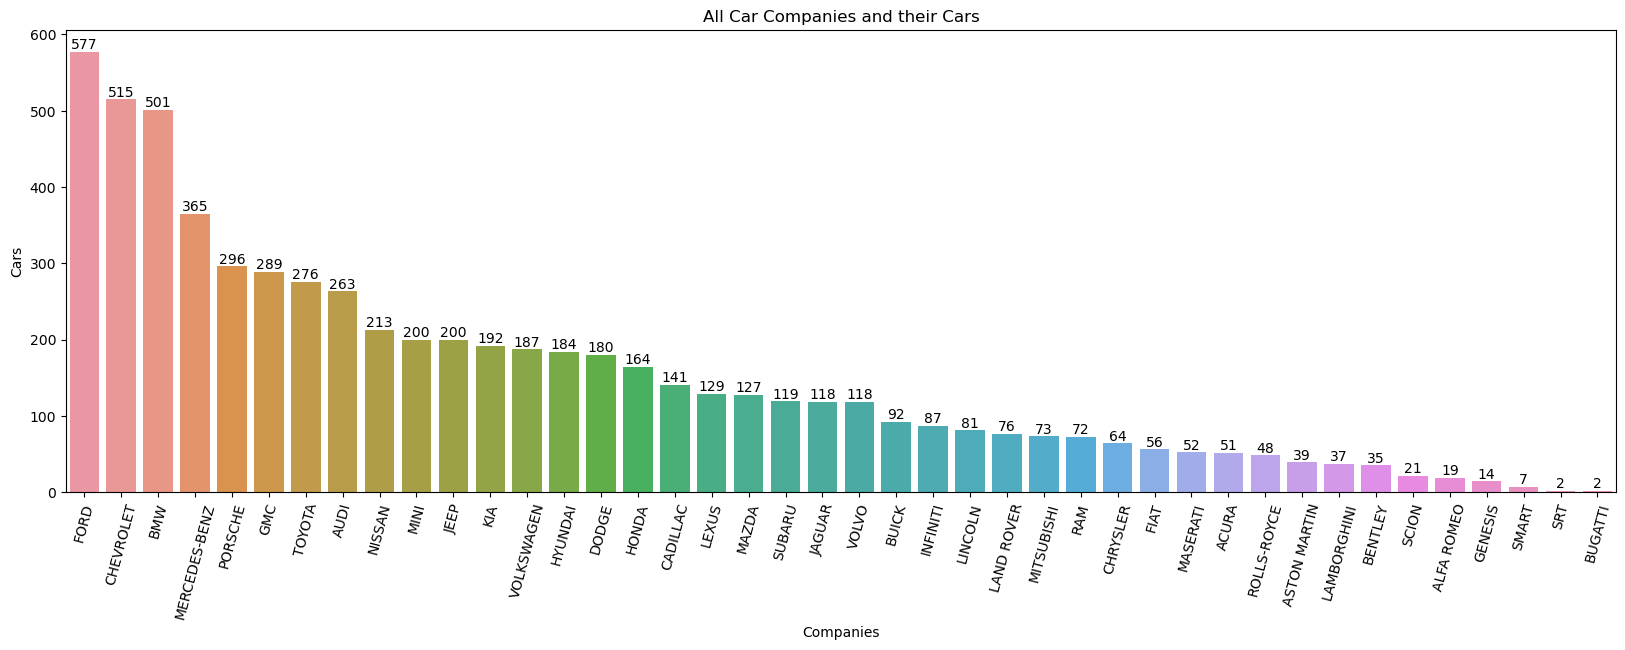

In [20]:
plt.figure(figsize=(20,6))
figure1 = sns.barplot(data = df_brand, x = "index",  y= "Make")
plt.xticks(rotation = 75)
plt.title("All Car Companies and their Cars")
plt.xlabel("Companies")
plt.ylabel("Cars")
plt.bar_label(figure1.containers[0])
plt.show()

In [21]:
print("We have total",len(df['Model'].unique()),"Vehicle Models")
df_model = df['Model'].value_counts().reset_index().rename(columns={'count':'Count'})[:25]
df_model.head(20)

We have total 2053 Vehicle Models


,index,Model
0,F-150 FFV,32
1,F-150 FFV 4X4,31
2,MUSTANG,27
3,FOCUS FFV,24
4,F-150 4X4,20
5,F-150,19
6,SONIC 5,18
7,ATS,18
8,JETTA,18
9,COMPASS,18


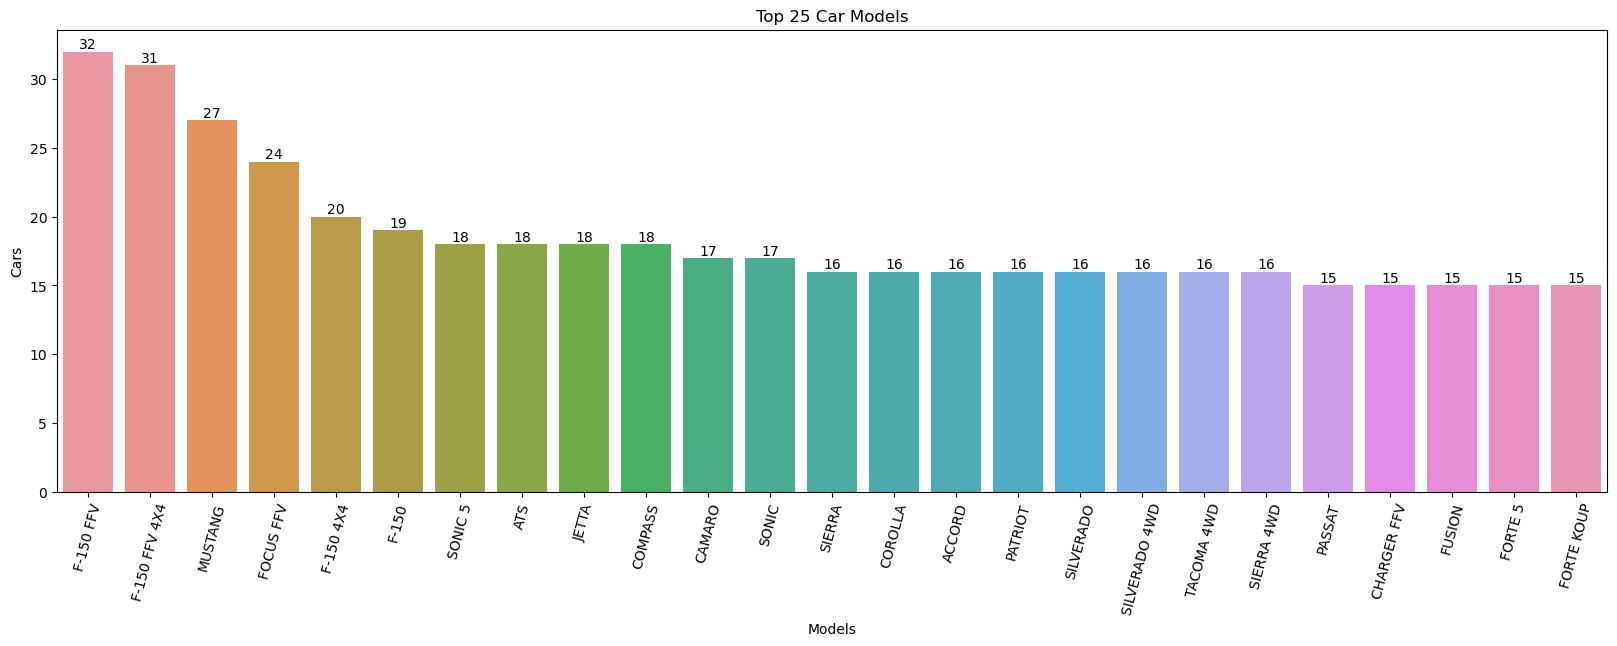

In [22]:
plt.figure(figsize=(20,6))
figure2 = sns.barplot(data = df_model, x = "index",  y= "Model")
plt.xticks(rotation = 75)
plt.title("Top 25 Car Models")
plt.xlabel("Models")
plt.ylabel("Cars")
plt.bar_label(figure2.containers[0])
plt.show()

In [23]:
print("We have total",len(df['Vehicle Class'].unique()),"Vehicle Class")
df_vehicle_class = df['Vehicle Class'].value_counts().reset_index().rename(columns={'count':'Count'})
df_vehicle_class

We have total 16 Vehicle Class


,index,Vehicle Class
0,SUV - SMALL,1006
1,MID-SIZE,983
2,COMPACT,903
3,SUV - STANDARD,613
4,SUBCOMPACT,533
5,FULL-SIZE,508
6,PICKUP TRUCK - STANDARD,475
7,TWO-SEATER,381
8,MINICOMPACT,274
9,STATION WAGON - SMALL,214


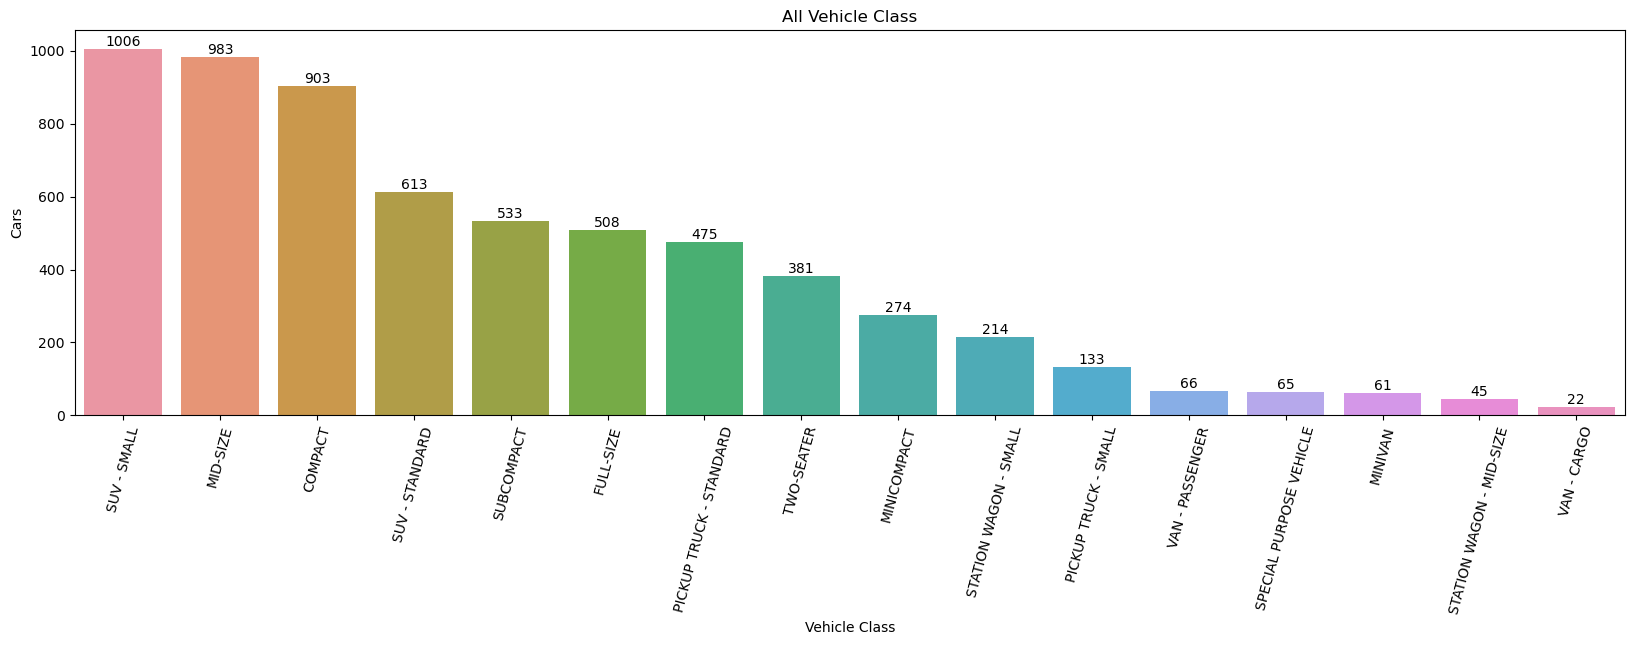

In [24]:
plt.figure(figsize=(20,5))
figure3 = sns.barplot(data = df_vehicle_class, x = "index",  y= "Vehicle Class")
plt.xticks(rotation = 75)
plt.title("All Vehicle Class")
plt.xlabel("Vehicle Class")
plt.ylabel("Cars")
plt.bar_label(figure3.containers[0])
plt.show()

In [25]:
print("We have total",len(df['Engine Size(L)'].unique()),"Types of Engine Size")
df_engine_size = df['Engine Size(L)'].value_counts().reset_index().rename(columns={'count':'Count'})
df_engine_size.head(20)

We have total 51 Types of Engine Size


,index,Engine Size(L)
0,2.0,1260
1,3.0,687
2,3.6,433
3,3.5,431
4,2.5,355
5,2.4,287
6,1.6,272
7,5.3,240
8,1.8,191
9,5.0,179


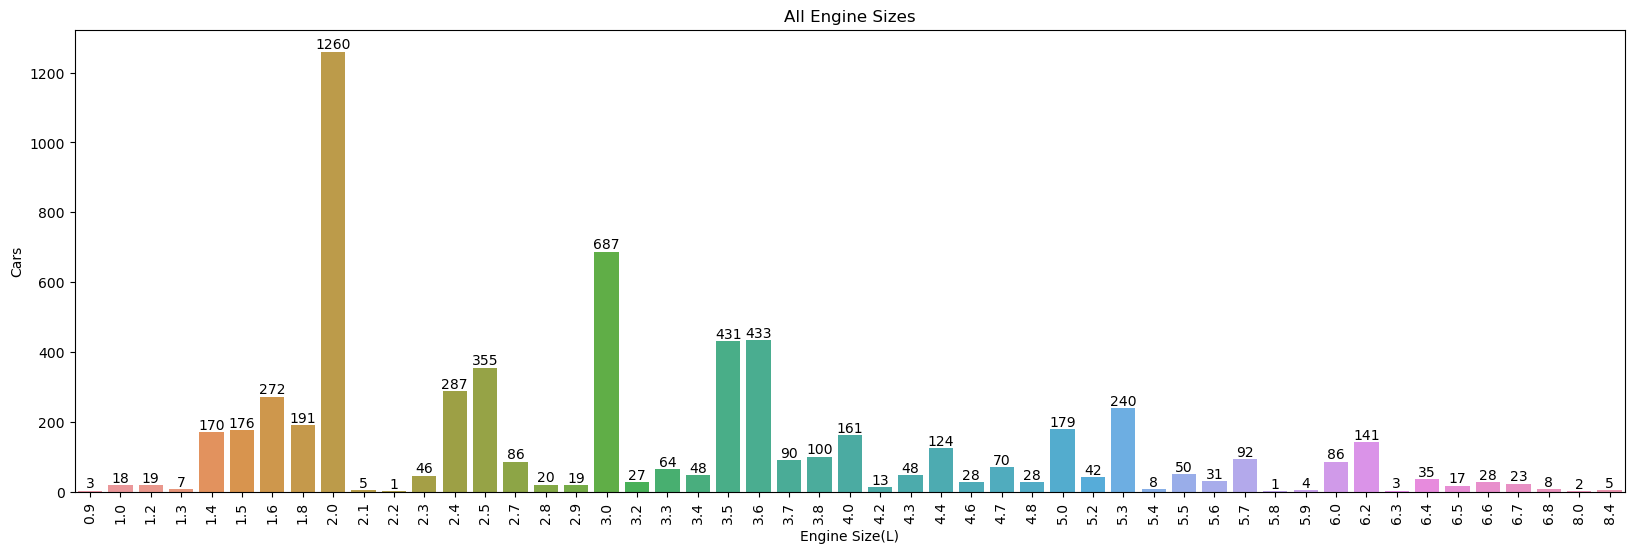

In [26]:
plt.figure(figsize=(20,6))
figure4 = sns.barplot(data = df_engine_size, x = "index",  y= "Engine Size(L)")
plt.xticks(rotation = 90)
plt.title("All Engine Sizes")
plt.xlabel("Engine Size(L)")
plt.ylabel("Cars")
plt.bar_label(figure4.containers[0])
plt.show()

In [27]:
print("We have total",len(df['Cylinders'].unique()),"Types of Cylinders")
df_cylinders = df['Cylinders'].value_counts().reset_index().rename(columns={'count':'Count'})
df_cylinders.head(20)

We have total 8 Types of Cylinders


,index,Cylinders
0,4,2749
1,6,2040
2,8,1202
3,12,135
4,3,88
5,10,40
6,5,26
7,16,2


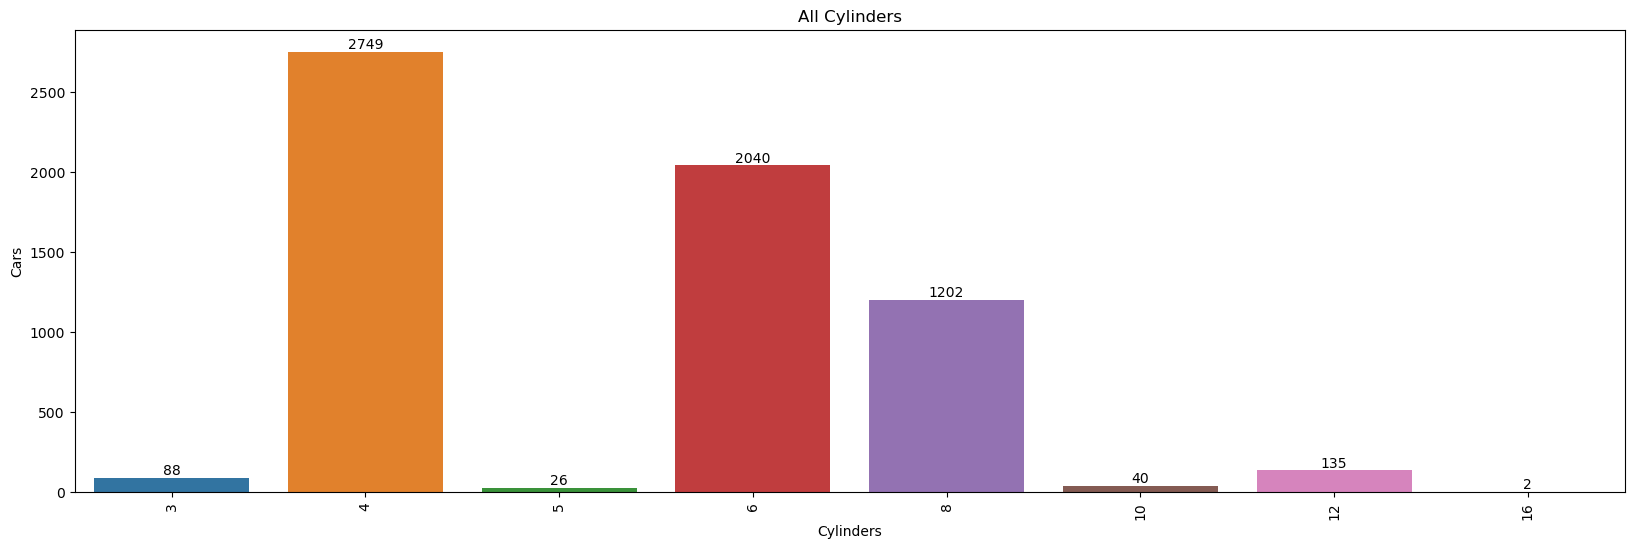

In [28]:
plt.figure(figsize=(20,6))
figure5 = sns.barplot(data = df_cylinders, x = "index",  y= "Cylinders")
plt.xticks(rotation = 90)
plt.title("All Cylinders")
plt.xlabel("Cylinders")
plt.ylabel("Cars")
plt.bar_label(figure5.containers[0])
plt.show()

In [29]:
df['Transmission'].unique()

array(['AS5', 'M6', 'AV7', 'AS6', 'AM6', 'A6', 'AM7', 'AV8', 'AS8', 'A7',
       'A8', 'M7', 'A4', 'M5', 'AV', 'A5', 'AS7', 'A9', 'AS9', 'AV6',
       'AS4', 'AM5', 'AM8', 'AM9', 'AS10', 'A10', 'AV10'], dtype=object)

In [30]:
df["Transmission"] = np.where(df["Transmission"].isin(["A4", "A5", "A6", "A7", "A8", "A9", "A10"]), "Automatic", df["Transmission"])
df["Transmission"] = np.where(df["Transmission"].isin(["AM5", "AM6", "AM7", "AM8", "AM9"]), "Automated Manual", df["Transmission"])
df["Transmission"] = np.where(df["Transmission"].isin(["AS4", "AS5", "AS6", "AS7", "AS8", "AS9", "AS10"]), "Automatic with Select Shift", df["Transmission"])
df["Transmission"] = np.where(df["Transmission"].isin(["AV", "AV6", "AV7", "AV8", "AV10"]), "Continuously Variable", df["Transmission"])
df["Transmission"] = np.where(df["Transmission"].isin(["M5", "M6", "M7"]), "Manual", df["Transmission"])

In [31]:
print("We have total",len(df['Transmission'].unique()),"Transmissions")
df_transmission = df['Transmission'].value_counts().reset_index().rename(columns={'count':'Count'})
df_transmission

We have total 5 Transmissions


,index,Transmission
0,Automatic with Select Shift,2722
1,Automatic,1536
2,Manual,1019
3,Automated Manual,540
4,Continuously Variable,465


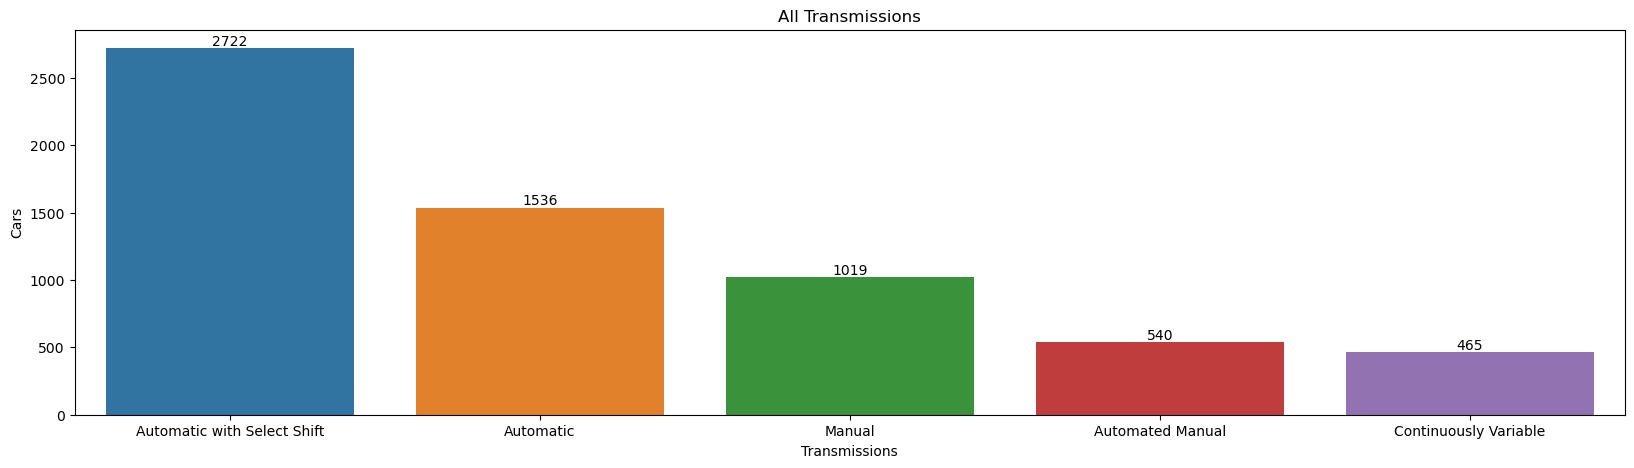

In [32]:
plt.figure(figsize=(20,5))
figure6 = sns.barplot(data = df_transmission, x = "index",  y= "Transmission")
plt.title("All Transmissions")
plt.xlabel("Transmissions")
plt.ylabel("Cars")
plt.bar_label(figure6.containers[0])
plt.show()

In [33]:
df['Fuel Type'].unique()

array(['Z', 'D', 'X', 'E', 'N'], dtype=object)

In [34]:
df["Fuel Type"] = np.where(df["Fuel Type"]=="Z", "Premium Gasoline", df["Fuel Type"])
df["Fuel Type"] = np.where(df["Fuel Type"]=="X", "Regular Gasoline", df["Fuel Type"])
df["Fuel Type"] = np.where(df["Fuel Type"]=="D", "Diesel", df["Fuel Type"])
df["Fuel Type"] = np.where(df["Fuel Type"]=="E", "Ethanol(E85)", df["Fuel Type"])
df["Fuel Type"] = np.where(df["Fuel Type"]=="N", "Natural Gas", df["Fuel Type"])

In [35]:
print("We have total",len(df['Fuel Type'].unique()),"Fuel Types")
df_fuel_type = df['Fuel Type'].value_counts().reset_index().rename(columns={'count':'Count'})
df_fuel_type

We have total 5 Fuel Types


,index,Fuel Type
0,Regular Gasoline,3039
1,Premium Gasoline,2765
2,Ethanol(E85),330
3,Diesel,147
4,Natural Gas,1


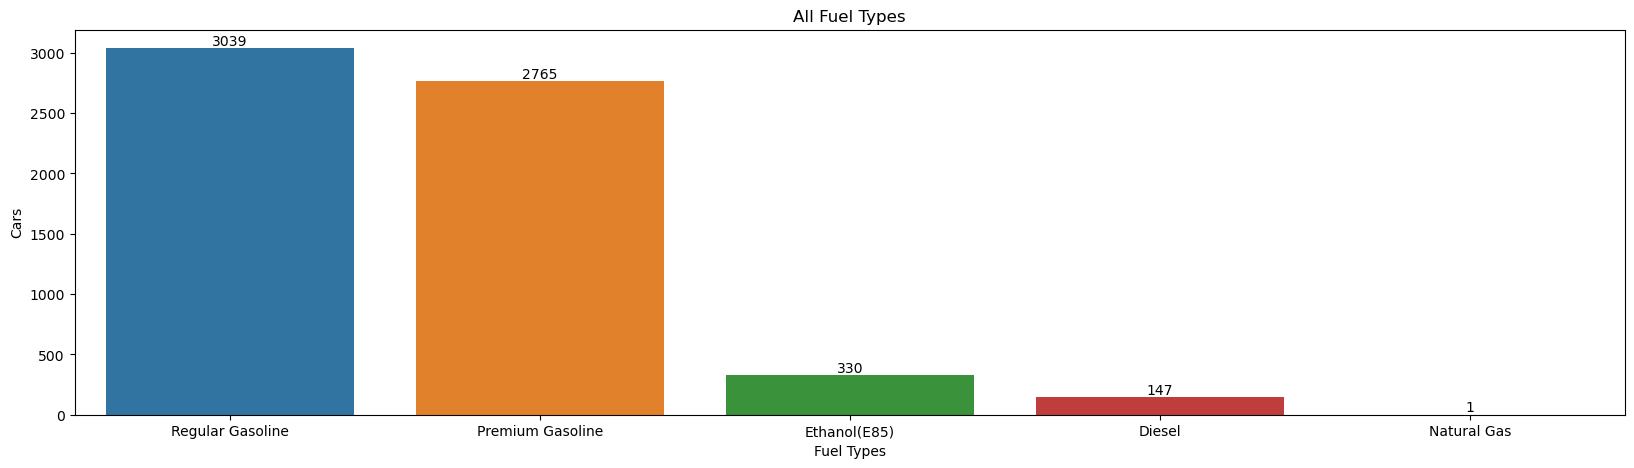

In [36]:
plt.figure(figsize=(20,5))
figure7 = sns.barplot(data = df_fuel_type, x = "index",  y= "Fuel Type")
plt.title("All Fuel Types")
plt.xlabel("Fuel Types")
plt.ylabel("Cars")
plt.bar_label(figure7.containers[0])
plt.show()

<Axes: xlabel='CO2 Emissions(g/km)', ylabel='Density'>

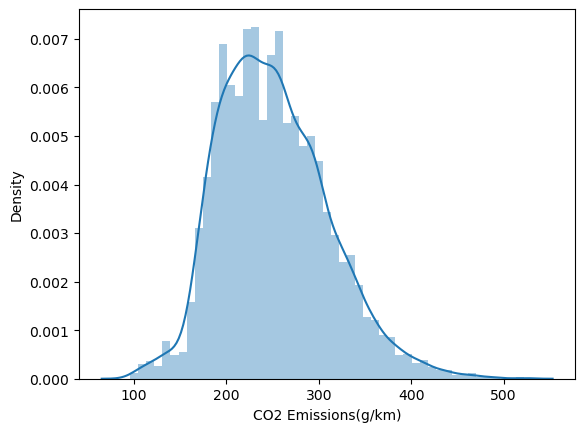

In [37]:
sns.distplot(df['CO2 Emissions(g/km)'])

<Axes: xlabel='Cylinders', ylabel='Density'>

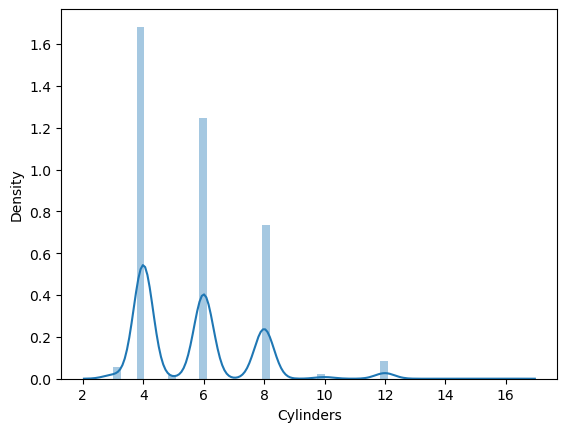

In [38]:
sns.distplot(df['Cylinders'])

<Axes: xlabel='Engine Size(L)', ylabel='Density'>

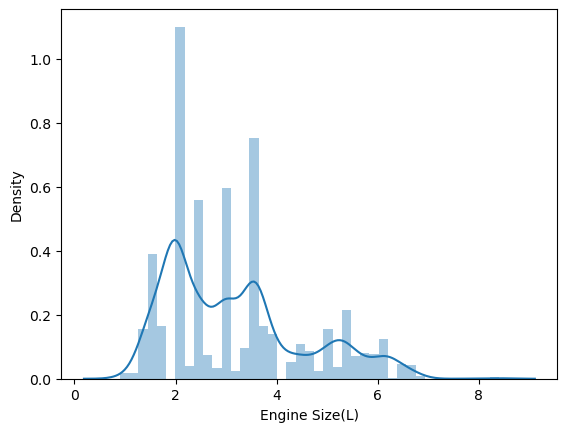

In [39]:
sns.distplot(df['Engine Size(L)'])

<Axes: xlabel='Fuel Consumption Comb (L/100 km)', ylabel='Density'>

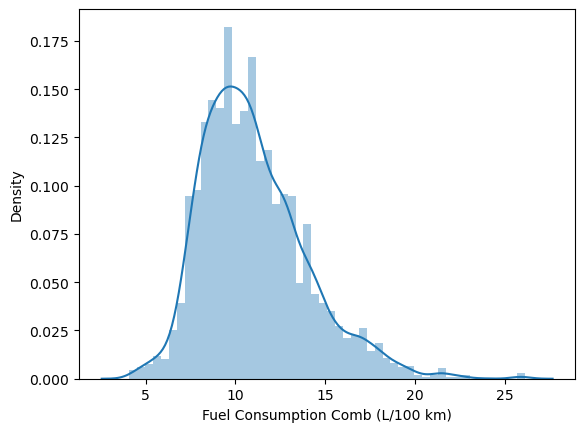

In [40]:
sns.distplot(df['Fuel Consumption Comb (L/100 km)'])

Variation of the CO2 emission with other features

In [41]:
df_co2_make = df.groupby(['Make'])['CO2 Emissions(g/km)'].mean().sort_values().reset_index()

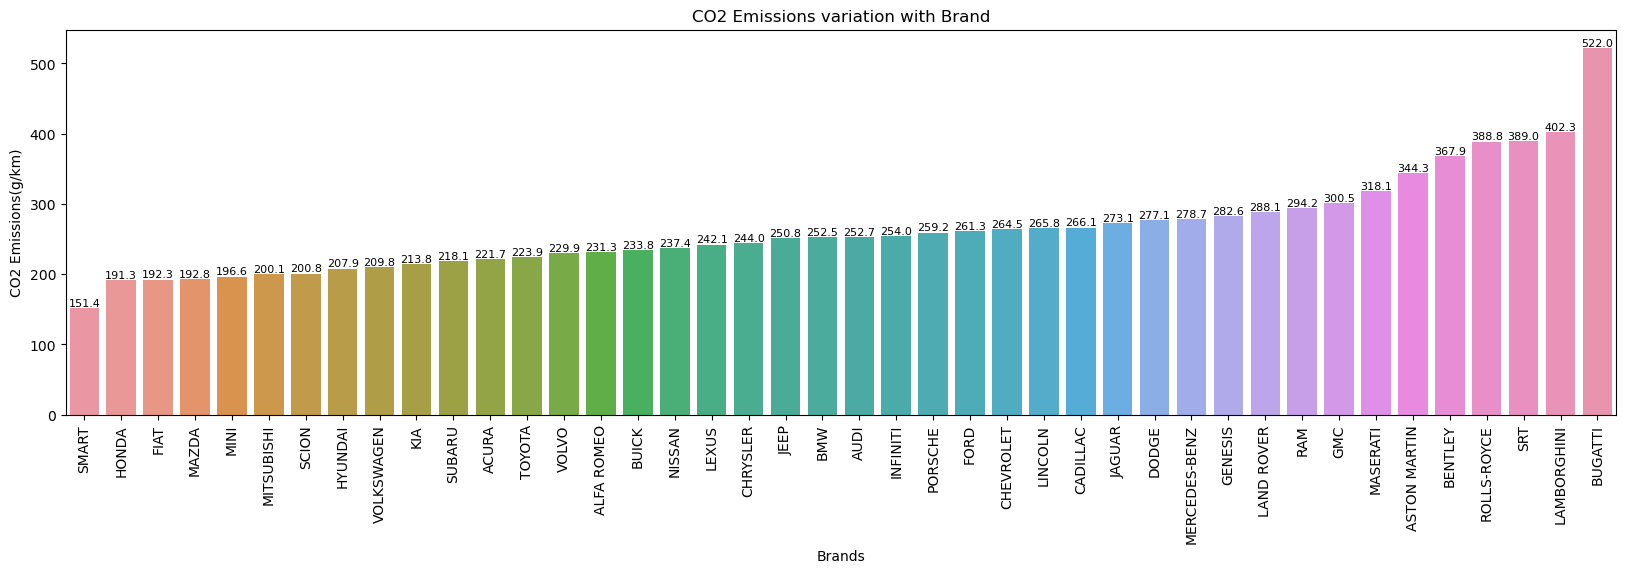

In [42]:
plt.figure(figsize=(20,5))
figure8 = sns.barplot(data = df_co2_make, x = "Make",  y= "CO2 Emissions(g/km)")
plt.xticks(rotation = 90)
plt.title("CO2 Emissions variation with Brand")
plt.xlabel("Brands")
plt.ylabel("CO2 Emissions(g/km)")
plt.bar_label(figure8.containers[0], fontsize=8, fmt='%.1f')
plt.show()

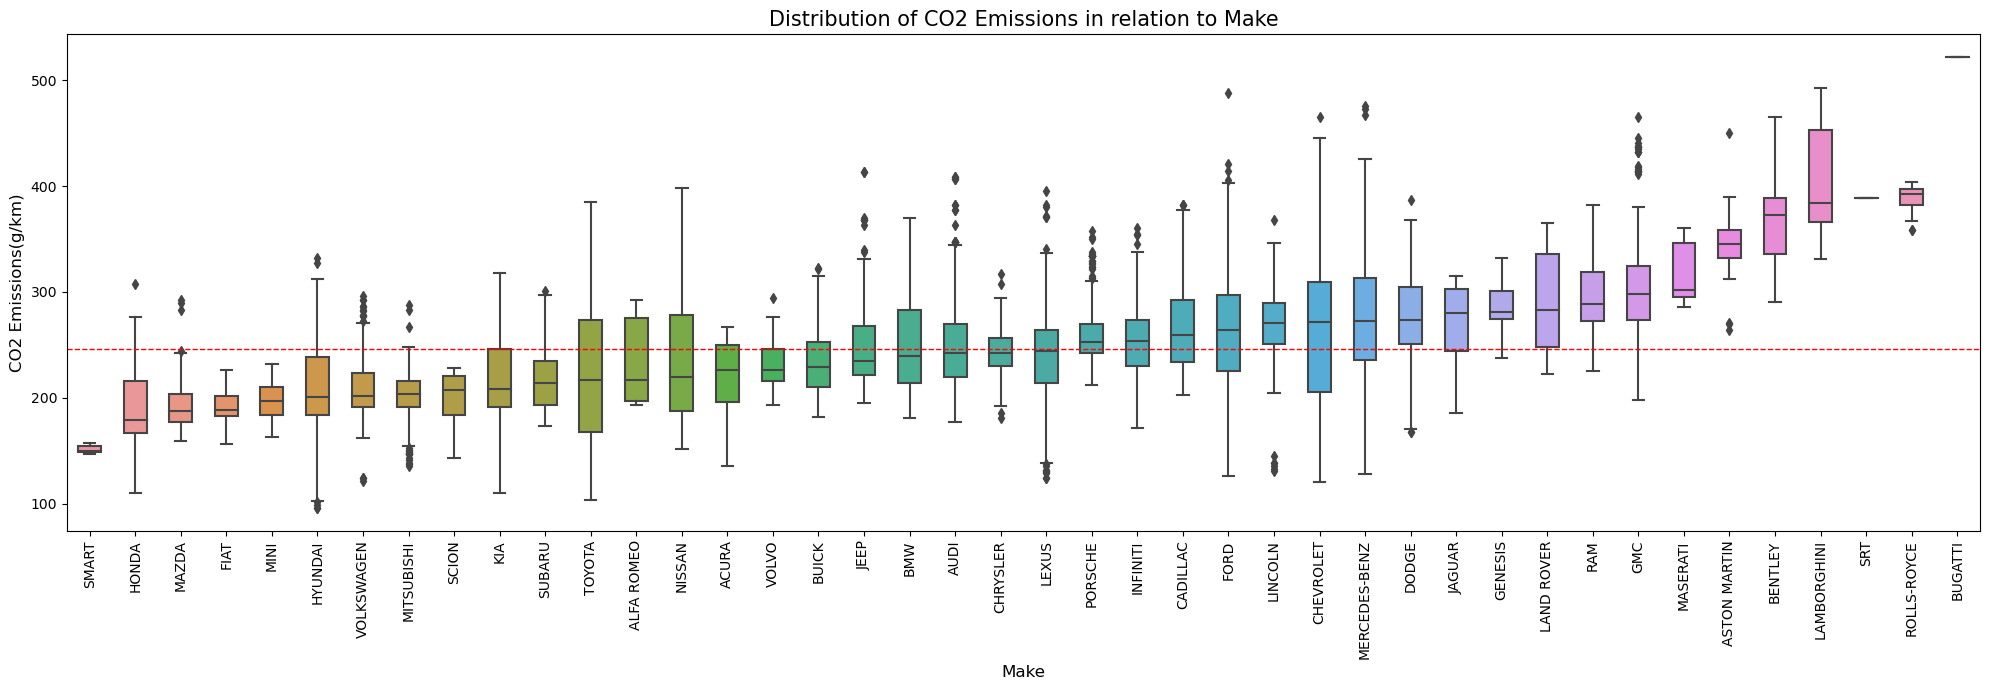

In [43]:
plt.figure(figsize=(20,7))
order = df.groupby("Make")["CO2 Emissions(g/km)"].median().sort_values(ascending=True).index
sns.boxplot(x="Make", y="CO2 Emissions(g/km)", data=df, order=order, width=0.5)
plt.title("Distribution of CO2 Emissions in relation to Make", fontsize=15)
plt.xticks(rotation=90, horizontalalignment='center')
plt.xlabel("Make", fontsize=12)
plt.ylabel("CO2 Emissions(g/km)", fontsize=12)
plt.axhline(df["CO2 Emissions(g/km)"].median(),color='r',linestyle='dashed',linewidth=1)
plt.tight_layout()
plt.show()

In [44]:
df_co2_vehicle_class = df.groupby(['Vehicle Class'])['CO2 Emissions(g/km)'].mean().sort_values().reset_index()

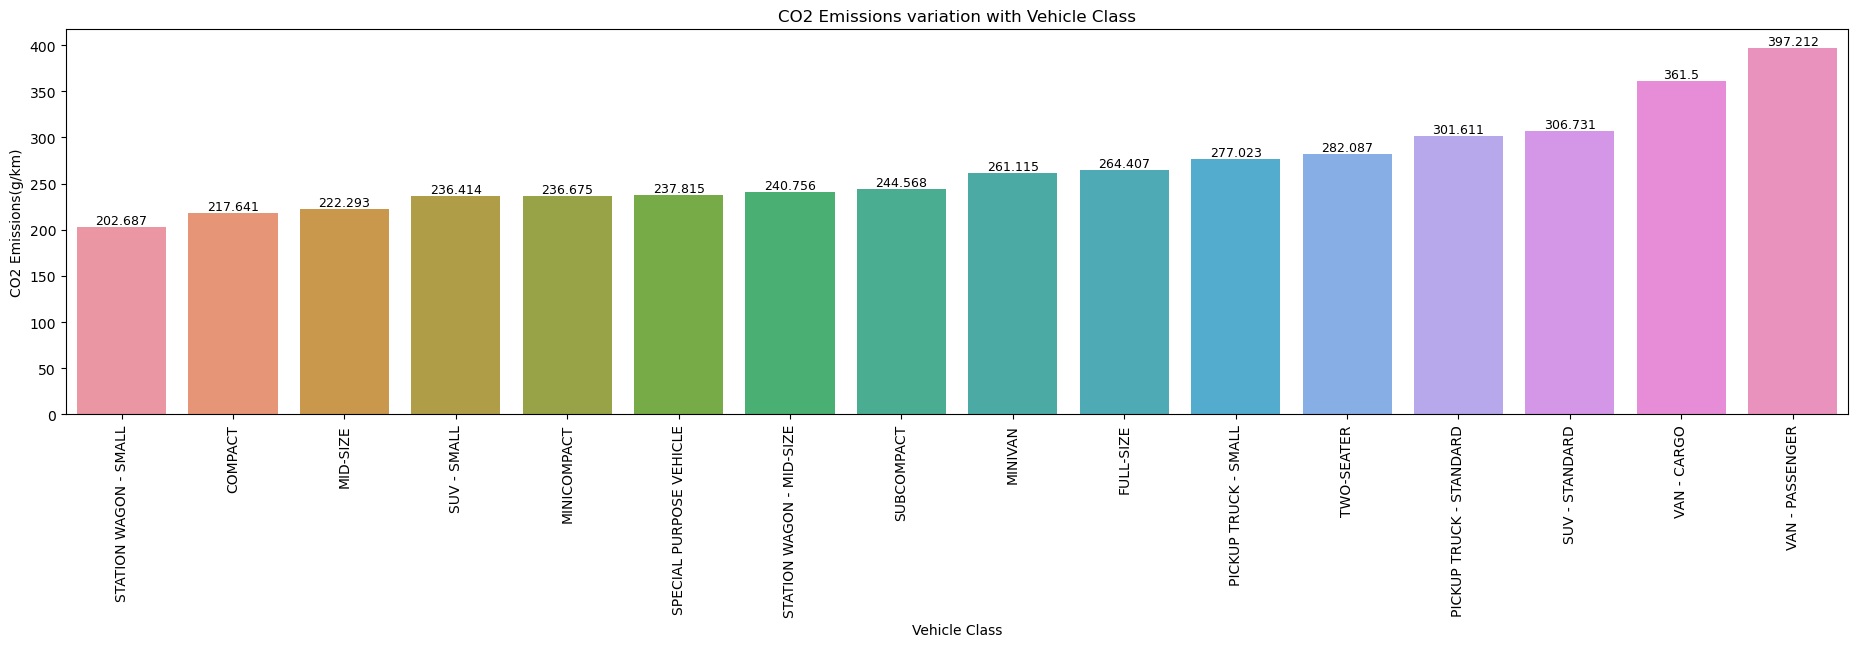

In [45]:
plt.figure(figsize=(23,5))
figure9 = sns.barplot(data = df_co2_vehicle_class, x = "Vehicle Class",  y= "CO2 Emissions(g/km)")
plt.xticks(rotation = 90)
plt.title("CO2 Emissions variation with Vehicle Class")
plt.xlabel("Vehicle Class")
plt.ylabel("CO2 Emissions(g/km)")
plt.bar_label(figure9.containers[0], fontsize=9)
plt.show()

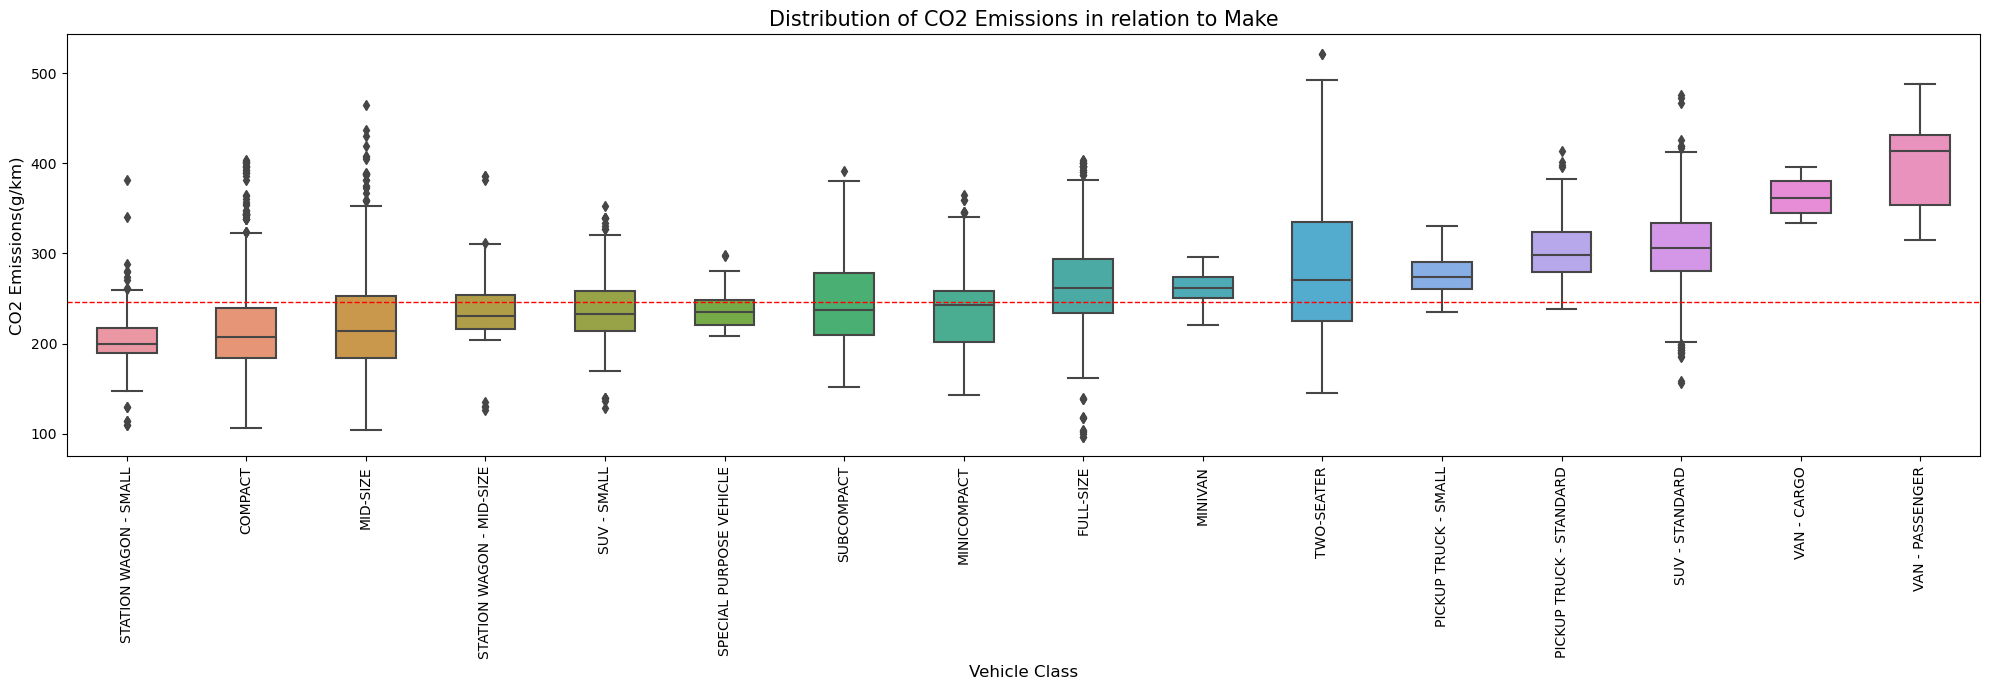

In [46]:
plt.figure(figsize=(20,7))
order = df.groupby("Vehicle Class")["CO2 Emissions(g/km)"].median().sort_values(ascending=True).index
sns.boxplot(x="Vehicle Class", y="CO2 Emissions(g/km)", data=df, order=order, width=0.5)
plt.title("Distribution of CO2 Emissions in relation to Make", fontsize=15)
plt.xticks(rotation=90, horizontalalignment='center')
plt.xlabel("Vehicle Class", fontsize=12)
plt.ylabel("CO2 Emissions(g/km)", fontsize=12)
plt.axhline(df["CO2 Emissions(g/km)"].median(),color='r',linestyle='dashed',linewidth=1)
plt.tight_layout()
plt.show()

In [47]:
df_co2_transmission = df.groupby(['Transmission'])['CO2 Emissions(g/km)'].mean().sort_values().reset_index()

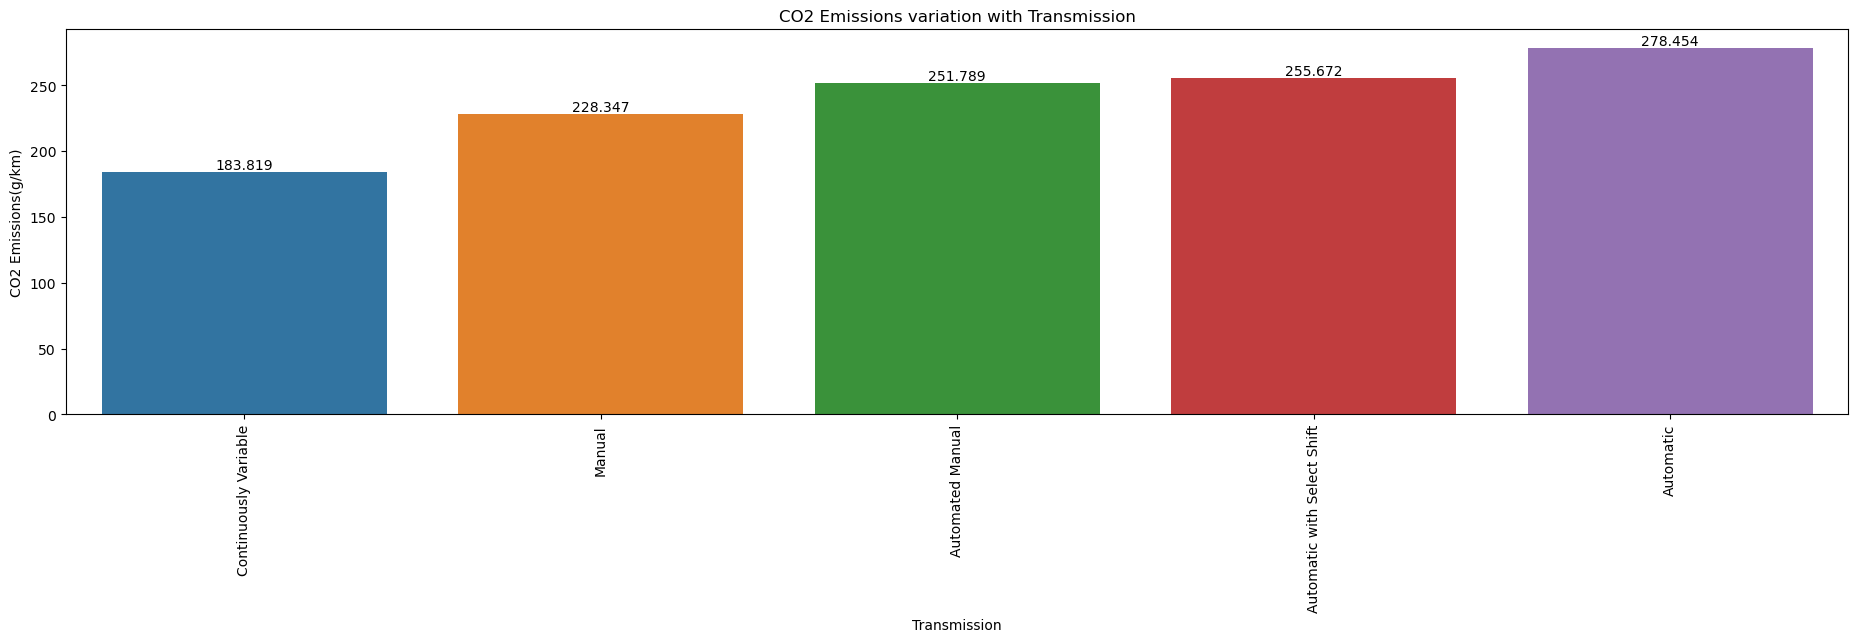

In [48]:
plt.figure(figsize=(23,5))
figure10 = sns.barplot(data = df_co2_transmission, x = "Transmission",  y= "CO2 Emissions(g/km)")
plt.xticks(rotation = 90)
plt.title("CO2 Emissions variation with Transmission")
plt.xlabel("Transmission")
plt.ylabel("CO2 Emissions(g/km)")
plt.bar_label(figure10.containers[0], fontsize=10)
plt.show()

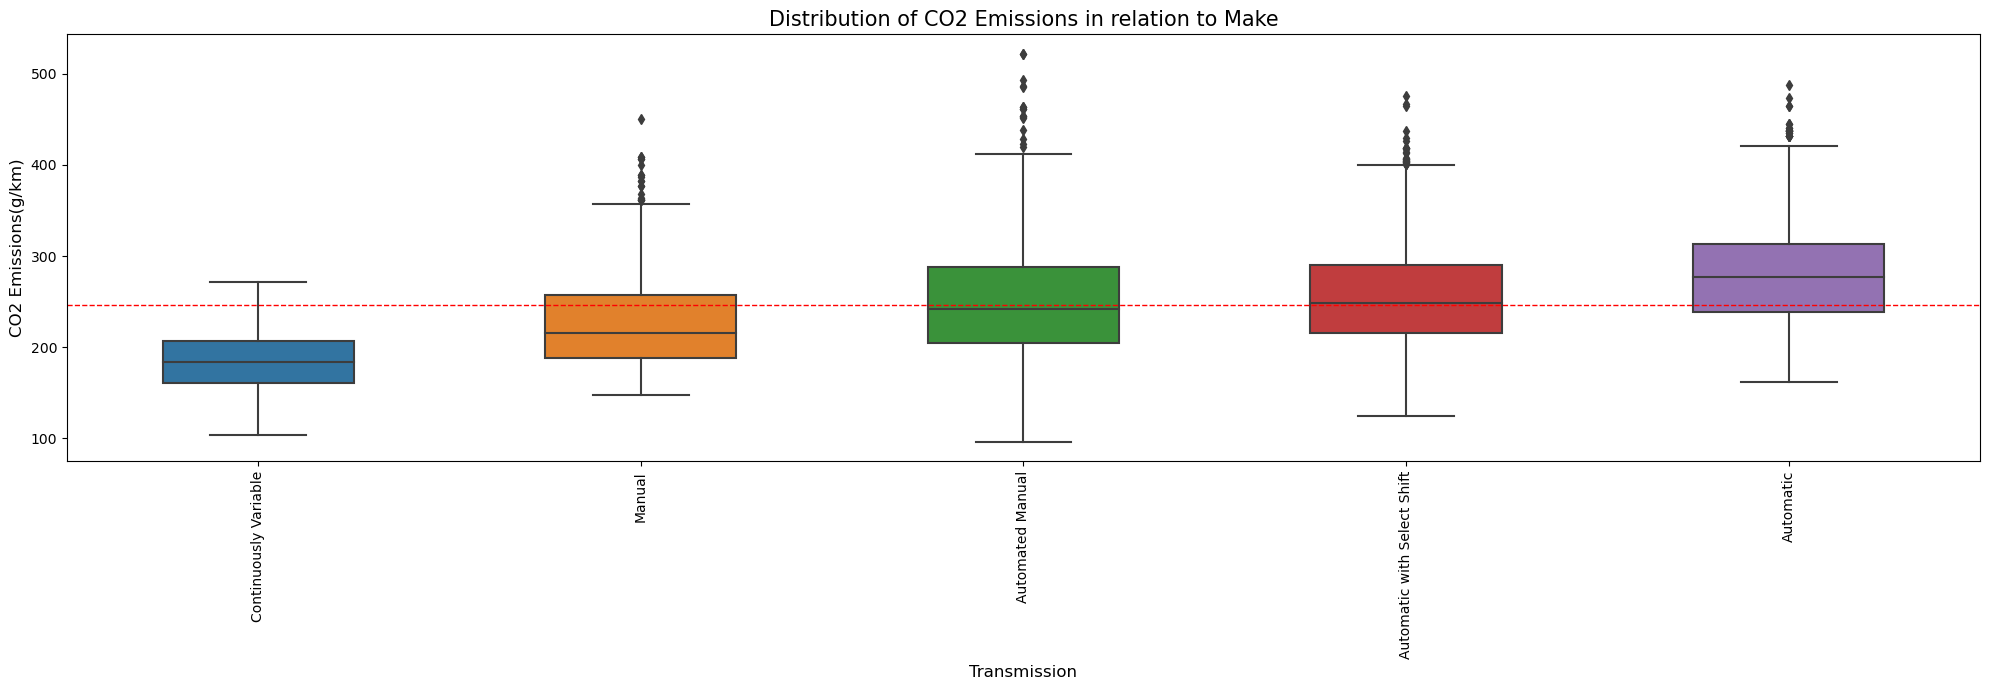

In [49]:
plt.figure(figsize=(20,7))
order = df.groupby("Transmission")["CO2 Emissions(g/km)"].median().sort_values(ascending=True).index
sns.boxplot(x="Transmission", y="CO2 Emissions(g/km)", data=df, order=order, width=0.5)
plt.title("Distribution of CO2 Emissions in relation to Make", fontsize=15)
plt.xticks(rotation=90, horizontalalignment='center')
plt.xlabel("Transmission", fontsize=12)
plt.ylabel("CO2 Emissions(g/km)", fontsize=12)
plt.axhline(df["CO2 Emissions(g/km)"].median(),color='r',linestyle='dashed',linewidth=1)
plt.tight_layout()
plt.show()

In [50]:
df_co2_fuel_type = df.groupby(['Fuel Type'])['CO2 Emissions(g/km)'].mean().sort_values().reset_index()

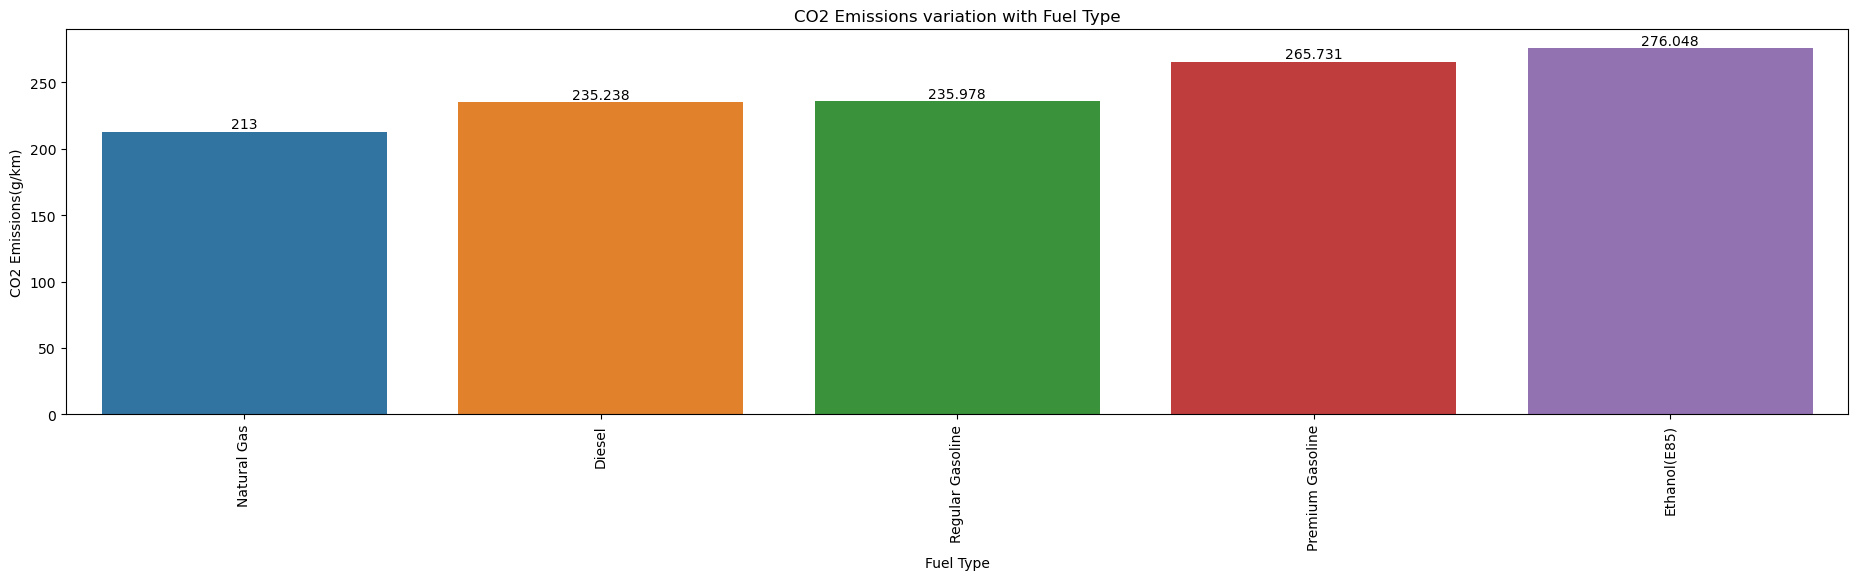

In [51]:
plt.figure(figsize=(23,5))
figure11 = sns.barplot(data = df_co2_fuel_type, x = "Fuel Type",  y= "CO2 Emissions(g/km)")
plt.xticks(rotation = 90)
plt.title("CO2 Emissions variation with Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("CO2 Emissions(g/km)")
plt.bar_label(figure11.containers[0], fontsize=10)
plt.show()

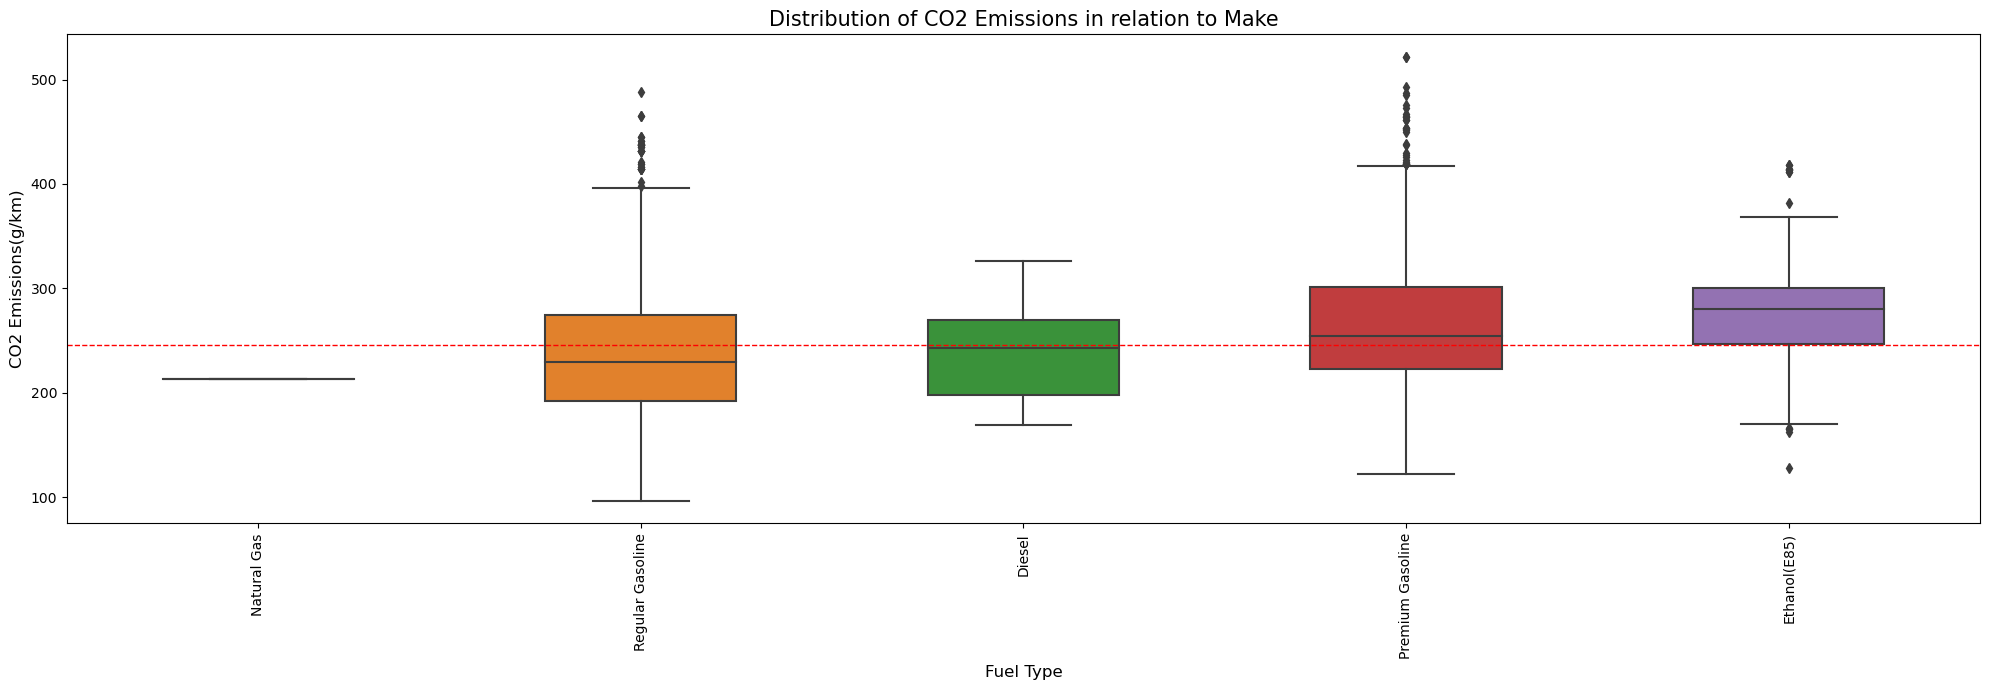

In [52]:
plt.figure(figsize=(20,7))
order = df.groupby("Fuel Type")["CO2 Emissions(g/km)"].median().sort_values(ascending=True).index
sns.boxplot(x="Fuel Type", y="CO2 Emissions(g/km)", data=df, order=order, width=0.5)
plt.title("Distribution of CO2 Emissions in relation to Make", fontsize=15)
plt.xticks(rotation=90, horizontalalignment='center')
plt.xlabel("Fuel Type", fontsize=12)
plt.ylabel("CO2 Emissions(g/km)", fontsize=12)
plt.axhline(df["CO2 Emissions(g/km)"].median(),color='r',linestyle='dashed',linewidth=1)
plt.tight_layout()
plt.show()

In [53]:
df_natural=df[df["Fuel Type"]=="Natural Gas"]
natural=df_natural.index
df_natural

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
2232,CHEVROLET,IMPALA DUAL FUEL,MID-SIZE,3.6,6,Automatic with Select Shift,Natural Gas,15.2,9.5,12.7,22,213


In [54]:
# We have to remove Natural Gas from our data set as there is only one natural gas data
for i in natural:
    df.drop(i, axis = 0,inplace = True)

In [55]:
df.reset_index(drop=True, inplace=True)

In [56]:
df[df["Fuel Type"]=="Natural Gas"]

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)


In [57]:
df_correlation = df[['Engine Size(L)','Cylinders','Fuel Consumption Comb (L/100 km)','CO2 Emissions(g/km)']]
df_correlation.head()

,Engine Size(L),Cylinders,Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km)
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244


In [58]:
df_correlation.corr()

,Engine Size(L),Cylinders,Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km)
Engine Size(L),1.000000,0.928843,0.820145,0.854870
Cylinders,0.928843,1.000000,0.781104,0.834739
Fuel Consumption Comb (L/100 km),0.820145,0.781104,1.000000,0.916953
CO2 Emissions(g/km),0.854870,0.834739,0.916953,1.000000


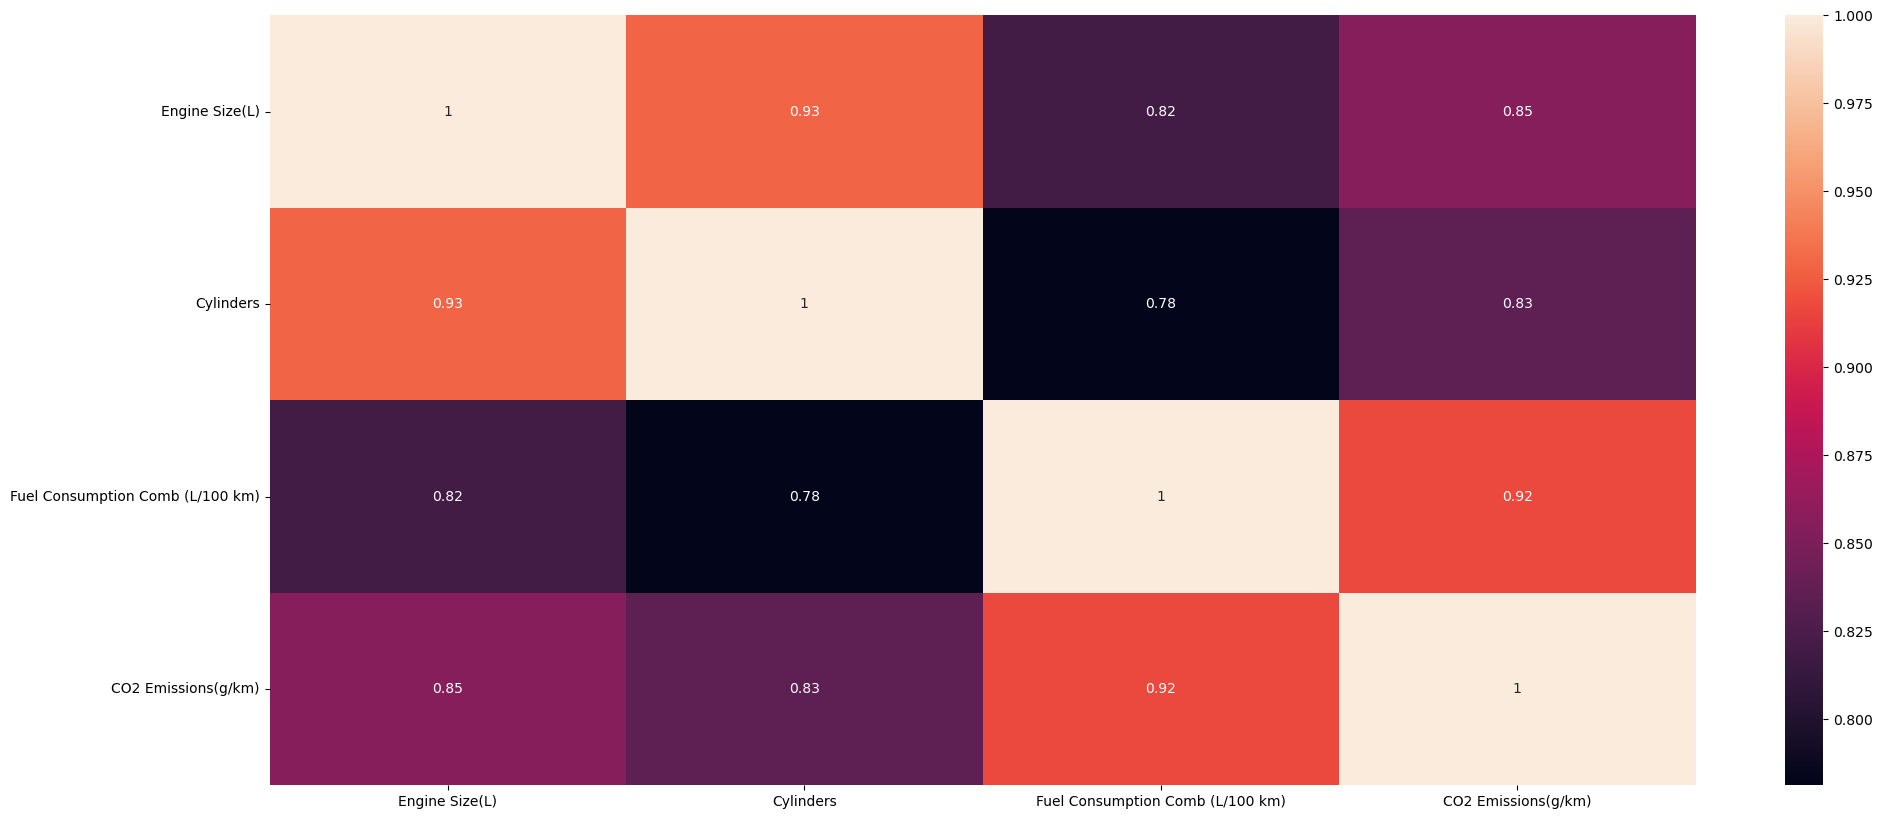

In [59]:
plt.figure(figsize = (23,10))
sns.heatmap(df_correlation.corr(), annot = True)
plt.show()

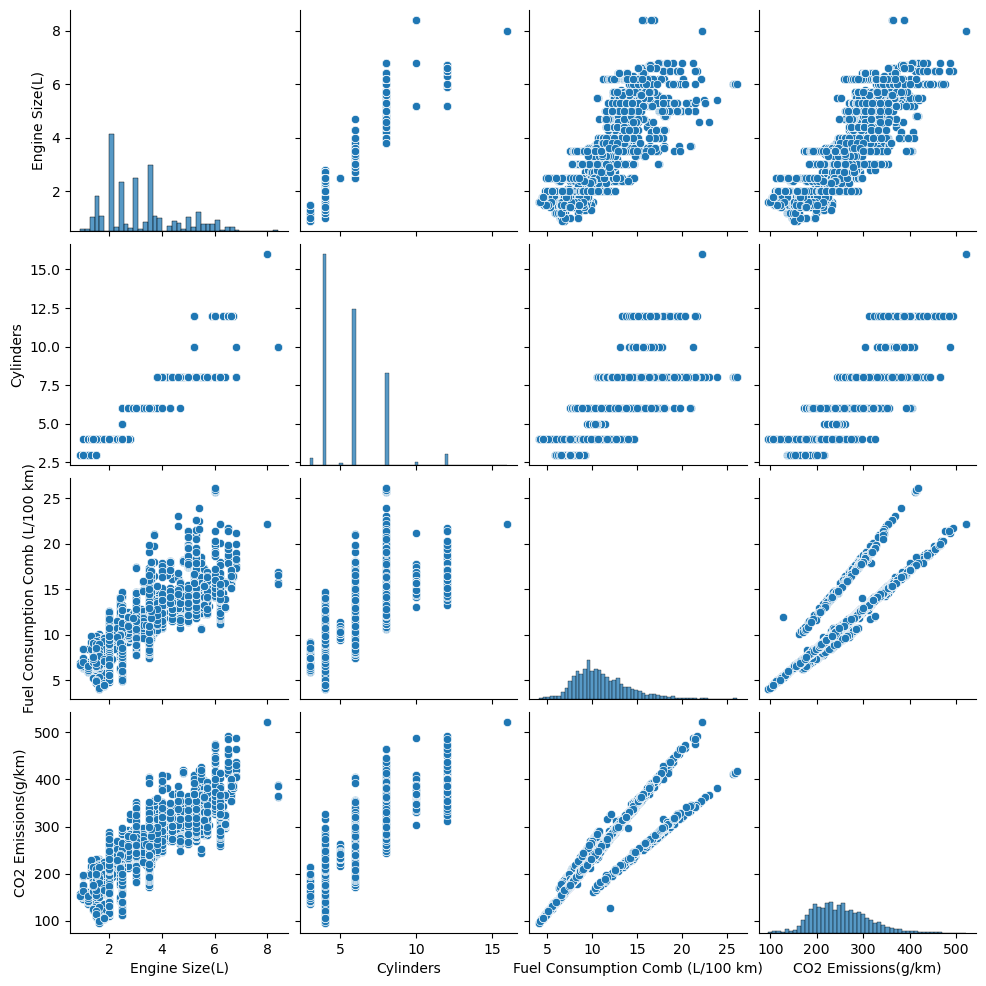

In [60]:
sns.pairplot(df_correlation)

# Outliers

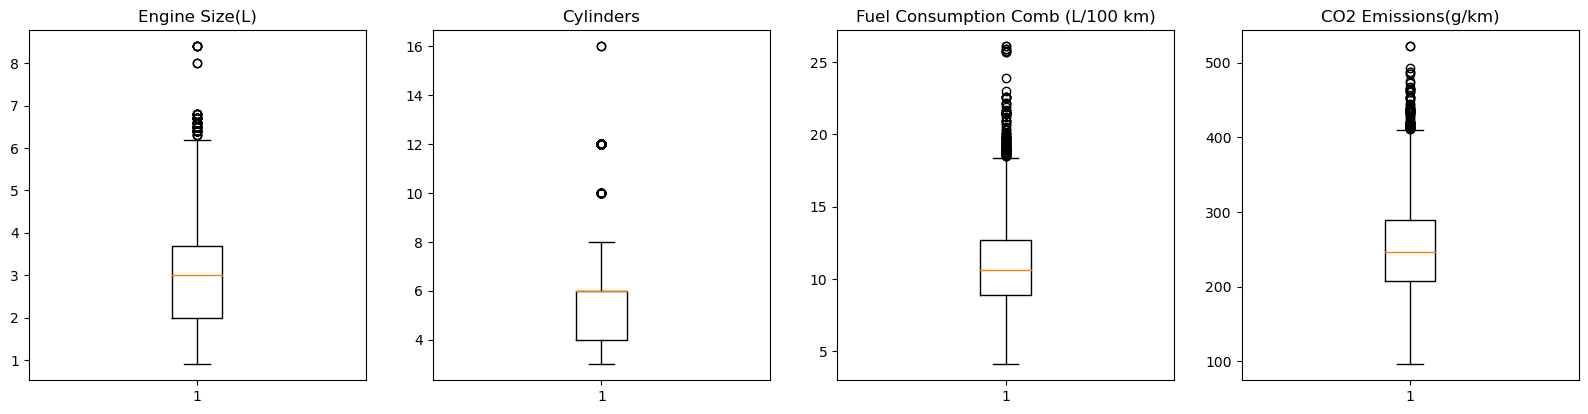

In [61]:
plt.figure(figsize = (20,10))
for i in enumerate(df_correlation):
    plt.subplot(2,4,i[0]+1)
    plt.title(i[1])
    plt.boxplot(df_correlation[i[1]])

In [62]:
#removing the outliers
df_new = df_correlation[(np.abs(stats.zscore(df_correlation)) < 1.9).all(axis=1)]

In [63]:
df_new.reset_index(drop=True, inplace=True)

In [64]:
df_new.head()

,Engine Size(L),Cylinders,Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km)
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,3.5,6,11.1,255
3,3.5,6,10.6,244
4,3.5,6,10.0,230


In [65]:
print("The length of the original : " , len(df))
print("The length after removing the outliers : " , len(df_new))
print("We just Removed",len(df)-len(df_new),"Outliers")

The length of the original :  6281
The length after removing the outliers :  5526
We just Removed 755 Outliers


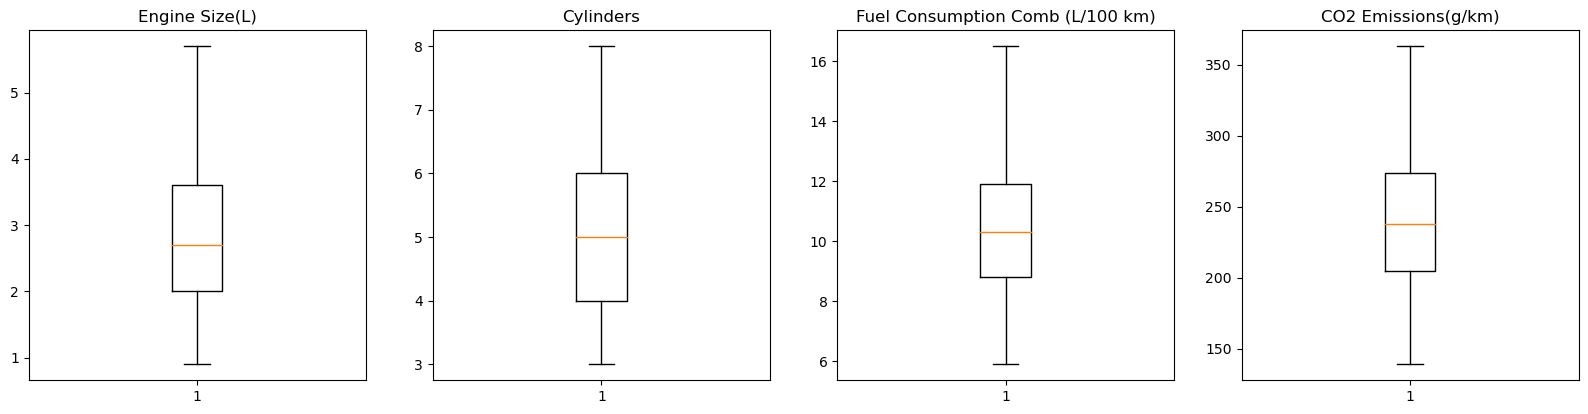

In [66]:
plt.figure(figsize = (20,10))
for i in enumerate(df_new):
    plt.subplot(2,4,i[0]+1)
    plt.title(i[1])
    plt.boxplot(df_new[i[1]])

In [67]:
# with outliers
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine Size(L),6281.0,3.161742,1.365299,0.9,2.0,3.0,3.7,8.4
Cylinders,6281.0,5.618851,1.846391,3.0,4.0,6.0,6.0,16.0
Fuel Consumption City (L/100 km),6281.0,12.609807,3.553199,4.2,10.1,12.1,14.7,30.6
Fuel Consumption Hwy (L/100 km),6281.0,9.070514,2.279059,4.0,7.5,8.7,10.3,20.6
Fuel Consumption Comb (L/100 km),6281.0,11.017609,2.947034,4.1,8.9,10.6,12.7,26.1
Fuel Consumption Comb (mpg),6281.0,27.411877,7.245573,11.0,22.0,27.0,32.0,69.0
CO2 Emissions(g/km),6281.0,251.163827,59.293191,96.0,208.0,246.0,289.0,522.0


In [68]:
# without outliers
df_new.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine Size(L),5526.0,2.882410,1.081911,0.9,2.0,2.7,3.6,5.7
Cylinders,5526.0,5.267101,1.445715,3.0,4.0,5.0,6.0,8.0
Fuel Consumption Comb (L/100 km),5526.0,10.443015,2.115111,5.9,8.8,10.3,11.9,16.5
CO2 Emissions(g/km),5526.0,241.733261,46.901574,139.0,205.0,238.0,274.0,363.0


In [69]:
df_new.head()

,Engine Size(L),Cylinders,Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km)
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,3.5,6,11.1,255
3,3.5,6,10.6,244
4,3.5,6,10.0,230


In [70]:
X = df.drop("CO2 Emissions(g/km)", axis=1)
y = df["CO2 Emissions(g/km)"]

In [71]:
X.head() # features

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg)
0,ACURA,ILX,COMPACT,2.0,4,Automatic with Select Shift,Premium Gasoline,9.9,6.7,8.5,33
1,ACURA,ILX,COMPACT,2.4,4,Manual,Premium Gasoline,11.2,7.7,9.6,29
2,ACURA,ILX HYBRID,COMPACT,1.5,4,Continuously Variable,Premium Gasoline,6.0,5.8,5.9,48
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,Automatic with Select Shift,Premium Gasoline,12.7,9.1,11.1,25
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,Automatic with Select Shift,Premium Gasoline,12.1,8.7,10.6,27


In [72]:
y.head()

0    196
1    221
2    136
3    255
4    244
Name: CO2 Emissions(g/km), dtype: int64

# Linear Regression Model

In [73]:
df["Fuel Type"].unique()

array(['Premium Gasoline', 'Diesel', 'Regular Gasoline', 'Ethanol(E85)'],
      dtype=object)

In [74]:
# Sampling
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                   test_size=0.05,
                                                   random_state=145)

In [75]:
X_train.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg)
10,ACURA,TSX,COMPACT,2.4,4,Manual,Premium Gasoline,11.2,8.1,9.8,29
4291,DODGE,CHARGER AWD (MDS),FULL-SIZE,5.7,8,Automatic,Regular Gasoline,16.0,10.1,13.3,21
4408,GMC,SIERRA 4WD FFV,PICKUP TRUCK - STANDARD,5.3,8,Automatic,Ethanol(E85),21.0,15.0,18.3,15
3867,MITSUBISHI,LANCER,COMPACT,2.4,4,Continuously Variable,Regular Gasoline,9.9,7.7,8.9,32
242,CHEVROLET,SILVERADO 4WD,PICKUP TRUCK - STANDARD,4.3,6,Automatic,Regular Gasoline,14.2,10.6,12.6,22


In [76]:
#y_train.head()

In [77]:
num_features = ["Engine Size(L)","Cylinders","Fuel Consumption Comb (L/100 km)"]
ord_features = []
nominal_features = ["Fuel Type"]
pass_through_cols = []
drop_cols = ["Fuel Consumption City (L/100 km)","Fuel Consumption Hwy (L/100 km)","Fuel Consumption Comb (mpg)","Transmission","Make","Model","Vehicle Class"]

In [78]:
numerical_pipeline = Pipeline([ ("imputer", SimpleImputer()), ("std scaler", StandardScaler())])
ordinal_pipeline = Pipeline([("ordinal encoder", OrdinalEncoder()),
                         ("std scaling", StandardScaler())
                        ])
nominal_pipeline = Pipeline([ ("one hot encoding", OneHotEncoder() ) ])

In [79]:
'''pipeline = ColumnTransformer([
    ("numerical pipeline", numerical_pipeline, num_features), #["Engine Size(L)","Cylinders","Fuel Consumption Comb (L/100 km)"]
    ("ordinal pipeline", ordinal_pipeline, ord_features), # []
    ("nominal pipeline", nominal_pipeline, nominal_features), # ["Diesel","Ethanol(E85)","Premium Gasoline","Regular Gasoline"]
    ("passing columns", "passthrough", pass_through_cols), # []
    ("drop columns", "drop", drop_cols)# ["Fuel Consumption City (L/100 km)","Fuel Consumption Hwy (L/100 km)","Fuel Consumption Comb (mpg)","Transmission","Make","Model","Vehicle Class"]

])'''

pipeline = ColumnTransformer([
    ("numerical pipeline", numerical_pipeline, num_features), 
    ("ordinal pipeline", ordinal_pipeline, ord_features),
    ("nominal pipeline", nominal_pipeline, nominal_features),
    ("passing columns", "passthrough", pass_through_cols),  # Corrected syntax
    ("drop columns", "drop", drop_cols)  # Corrected syntax
])

output_cols = ["Engine Size(L)","Cylinders","Fuel Consumption Comb (L/100 km)","Diesel","Ethanol(E85)","Premium Gasoline","Regular Gasoline"]
#output_cols = ["Engine Size(L)","Cylinders","Fuel Consumption Comb (L/100 km)","Fuel Type"]


In [80]:
df["Fuel Type"].unique()

array(['Premium Gasoline', 'Diesel', 'Regular Gasoline', 'Ethanol(E85)'],
      dtype=object)

In [81]:
X_train.head(2)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg)
10,ACURA,TSX,COMPACT,2.4,4,Manual,Premium Gasoline,11.2,8.1,9.8,29
4291,DODGE,CHARGER AWD (MDS),FULL-SIZE,5.7,8,Automatic,Regular Gasoline,16.0,10.1,13.3,21


In [82]:
X_train_tr = pipeline.fit_transform(X_train)
#X_train_tr.shape
X_train_tr = pd.DataFrame(X_train_tr, columns=output_cols)
X_train_tr.head(2)

,Engine Size(L),Cylinders,Fuel Consumption Comb (L/100 km),Diesel,Ethanol(E85),Premium Gasoline,Regular Gasoline
0,-0.557282,-0.876039,-0.411783,0.0,0.0,1.0,0.0
1,1.853965,1.287226,0.773834,0.0,0.0,0.0,1.0


In [83]:
'''# Fit the transformation pipeline to the training data
X_train_tr = pipeline.fit_transform(X_train)

# Check the number of columns in X_train_tr
num_columns = X_train_tr.shape[1]

# Ensure that the number of columns matches the length of output_cols
if num_columns != len(output_cols):
    raise ValueError("Number of columns in transformed data does not match the length of output_cols.")

# Create DataFrame with specified column names
X_train_tr = pd.DataFrame(X_train_tr, columns=output_cols)
X_train_tr.head(2)'''


'# Fit the transformation pipeline to the training data\nX_train_tr = pipeline.fit_transform(X_train)\n\n# Check the number of columns in X_train_tr\nnum_columns = X_train_tr.shape[1]\n\n# Ensure that the number of columns matches the length of output_cols\nif num_columns != len(output_cols):\n    raise ValueError("Number of columns in transformed data does not match the length of output_cols.")\n\n# Create DataFrame with specified column names\nX_train_tr = pd.DataFrame(X_train_tr, columns=output_cols)\nX_train_tr.head(2)'

In [84]:
X_test.head(2)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg)
884,PORSCHE,911 CARRERA S CABRIOLET,MINICOMPACT,3.8,6,Manual,Premium Gasoline,12.6,8.8,10.9,26
2547,HYUNDAI,VELOSTER TURBO,COMPACT,1.6,4,Manual,Regular Gasoline,9.4,7.0,8.3,34


In [85]:
X_test_tr = pipeline.transform(X_test)
X_test_tr = pd.DataFrame(X_test_tr, columns=output_cols)
X_test_tr.head(2)

,Engine Size(L),Cylinders,Fuel Consumption Comb (L/100 km),Diesel,Ethanol(E85),Premium Gasoline,Regular Gasoline
0,0.465671,0.205594,-0.039161,0.0,0.0,1.0,0.0
1,-1.141826,-0.876039,-0.919905,0.0,0.0,0.0,1.0


In [86]:
# ML
model = LinearRegression()
model.fit(X_train_tr, y_train)
print(model.intercept_, model.coef_)

235.56791868735303 [  0.39376389   1.24701459  65.59973414  50.57137106 -92.09341313
  20.84502774  20.67701433]


In [87]:
# ML

def generate_models_report(models, X_train_tr, y_train, X_test_tr, y_test):
    width = 116
    print("_"*width)
    title = "|{:^30}|{:^20}|{:^20}|{:^20}|{:^20}|"
    print(title.format("Model Name", "Train Error", "Test Error", "Train Accuracy", "Test Accuracy"))
    print("_"*width)
    row = "|{:^30}|{:^20.2f}|{:^20.2f}|{:^20.2f}|{:^20.2f}|"
    for model in models:
        model.fit(X_train_tr, y_train)
        y_hat_train = model.predict(X_train_tr)
        y_hat_test = model.predict(X_test_tr)
        train_error = rmse(y_train, y_hat_train)
        test_error = rmse(y_test, y_hat_test)
        train_accuracy = r2_score(y_train, y_hat_train)
        test_accuracy = r2_score(y_test, y_hat_test)
        model_name = str(model)
        print(row.format(model_name, train_error, test_error, train_accuracy*100, test_accuracy*100))
        print("-"*width)

In [88]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

models = [LinearRegression(), SGDRegressor(), SVR() ,DecisionTreeRegressor(), RandomForestRegressor(),  KNeighborsRegressor()]

In [89]:
generate_models_report(models, X_train_tr, y_train, X_test_tr, y_test)
# latest

____________________________________________________________________________________________________________________
|          Model Name          |    Train Error     |     Test Error     |   Train Accuracy   |   Test Accuracy    |
____________________________________________________________________________________________________________________
|      LinearRegression()      |        5.65        |        6.23        |       99.10        |       98.76        |
--------------------------------------------------------------------------------------------------------------------
|        SGDRegressor()        |        5.66        |        6.21        |       99.10        |       98.77        |
--------------------------------------------------------------------------------------------------------------------
|            SVR()             |       12.99        |       11.00        |       95.23        |       96.13        |
----------------------------------------------------------------

# Linear Regression graph

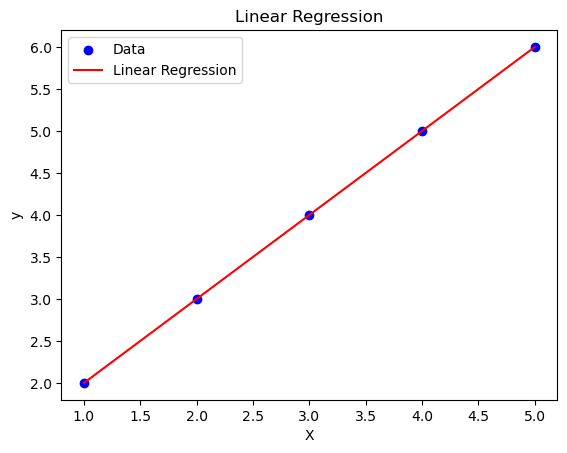

In [90]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Sample data
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([2, 3, 4, 5, 6])

# Fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Plot the data points
plt.scatter(X, y, color='blue', label='Data')

# Plot the regression line
plt.plot(X, model.predict(X), color='red', label='Linear Regression')

# Add labels and legend
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression')
plt.legend()

# Show plot
plt.show()
